# POC — OpenHousing: Real Estate Price Prediction (USD)

**Context**: Housing Observatory (OpenHousing) — public urban-planning organization.
**POC objective**: prove the technical feasibility of a model that predicts a property's price from socio-economic indicators. The POC is this notebook — nothing else (no API, no Docker, no CI/CD at this stage).

This notebook covers the POC user stories from the backlog (`BACKLOG_PRODUIT_v2.md`):
- `US-01` fetch the dataset
- `US-02` clean the data
- `US-03` exploratory data analysis (EDA)
- `US-07` train and compare several models (baseline + advanced models)
- `US-08` evaluate each model (RMSE / MAE / R²)
- `US-09` save the best model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Data Loading (US-01)

In [2]:
DATA_URL = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(DATA_URL)
print("Shape:", df.shape)
df.head()

Shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


**Note on the price unit**: in the original dataset, `medv` is the median price in **thousands of dollars**.
The use case requires a price in **USD**: we therefore create a `price_usd = medv * 1000` column.

In [3]:
df["price_usd"] = df["medv"] * 1000
df[["medv", "price_usd"]].head()

,medv,price_usd
0,24.0,24000.0
1,21.6,21600.0
2,34.7,34700.0
3,33.4,33400.0
4,36.2,36200.0


## 2. Exploratory Data Analysis — EDA (US-03)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   crim       506 non-null    float64
 1   zn         506 non-null    float64
 2   indus      506 non-null    float64
 3   chas       506 non-null    int64  
 4   nox        506 non-null    float64
 5   rm         506 non-null    float64
 6   age        506 non-null    float64
 7   dis        506 non-null    float64
 8   rad        506 non-null    int64  
 9   tax        506 non-null    int64  
 10  ptratio    506 non-null    float64
 11  b          506 non-null    float64
 12  lstat      506 non-null    float64
 13  medv       506 non-null    float64
 14  price_usd  506 non-null    float64
dtypes: float64(12), int64(3)
memory usage: 59.4 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
crim,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
zn,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
indus,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
chas,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
nox,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
rm,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
age,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
dis,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
rad,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
tax,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [6]:
missing = df.isna().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing if len(missing) else "None")

print("\nDuplicates:", df.duplicated().sum())

Columns with missing values:
None

Duplicates: 0


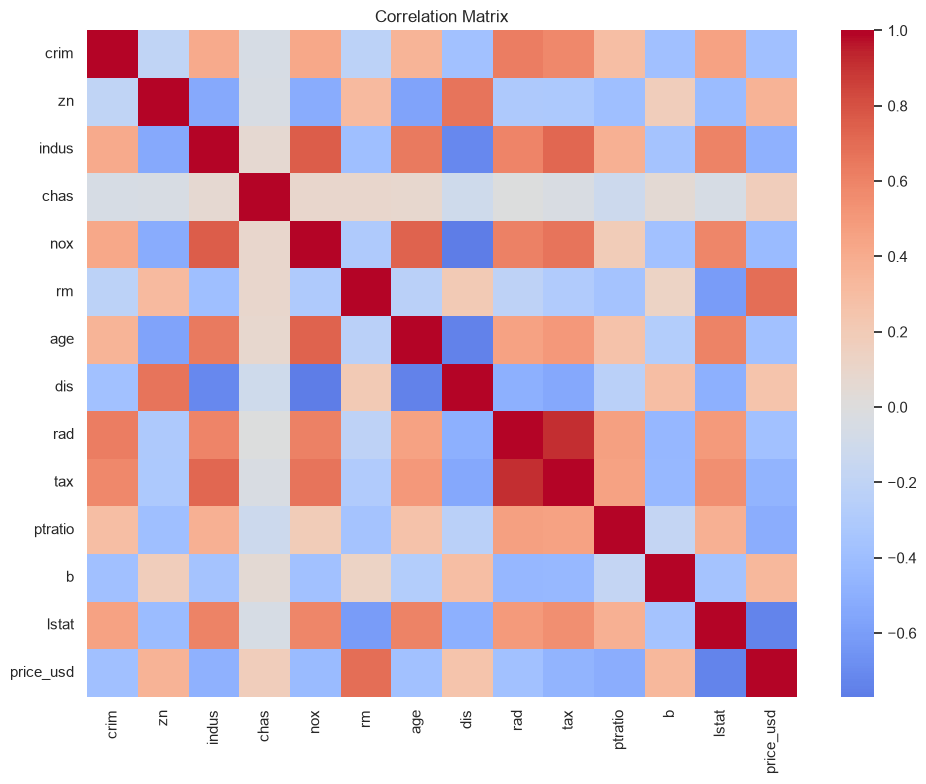

In [7]:
plt.figure(figsize=(10, 8))
corr = df.drop(columns=["medv"]).corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

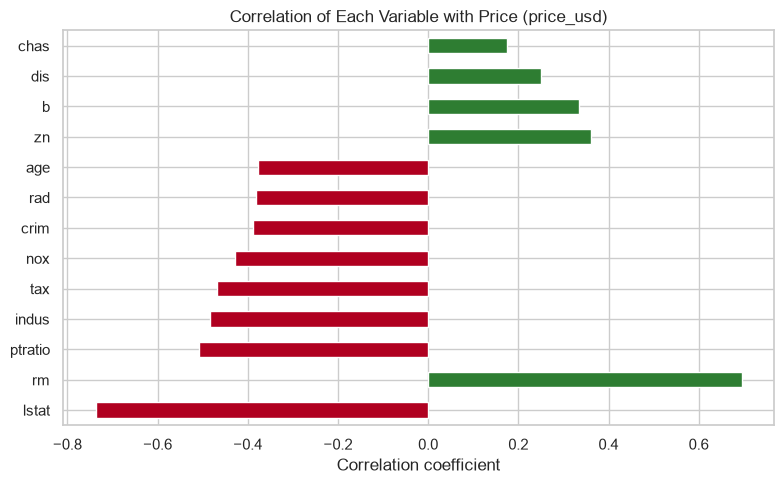

In [8]:
top_corr = corr["price_usd"].drop("price_usd").sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 5))
top_corr.plot(kind="barh", color=["#2E7D32" if v > 0 else "#B00020" for v in top_corr])
plt.title("Correlation of Each Variable with Price (price_usd)")
plt.xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

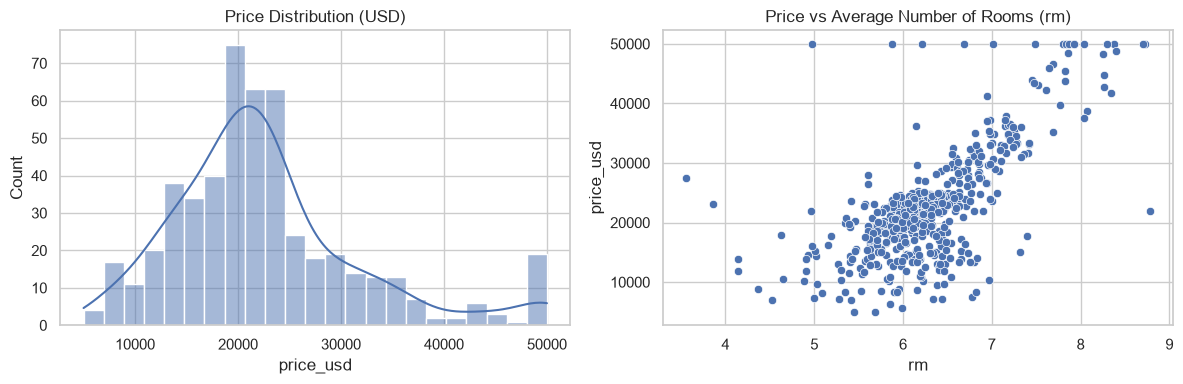

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["price_usd"], kde=True, ax=axes[0])
axes[0].set_title("Price Distribution (USD)")
sns.scatterplot(data=df, x="rm", y="price_usd", ax=axes[1])
axes[1].set_title("Price vs Average Number of Rooms (rm)")
plt.tight_layout()
plt.show()

## 3. Data Cleaning (US-02)

In [11]:
before = df.shape[0]

# Duplicates
df = df.drop_duplicates()

# Missing values: median imputation (POC — to be challenged if not acceptable for the MVP)
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

after = df.shape[0]
print(f"Rows before cleaning: {before} | after: {after}")
assert df.isna().sum().sum() == 0, "There are still missing values"

Rows before cleaning: 506 | after: 506


## 4. Training and Comparing Multiple Models (US-07)

In [12]:
FEATURES = [c for c in df.columns if c not in ("medv", "price_usd")]
TARGET = "price_usd"

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (404, 13)  Test: (102, 13)


In [13]:
models = {
    "Linear Regression":  LinearRegression(),
    "Ridge Regression":   Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest":      RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting":  GradientBoostingRegressor(random_state=RANDOM_STATE),
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
print("Trained models:", list(trained.keys()))

Trained models: ['Linear Regression', 'Ridge Regression', 'Random Forest', 'Gradient Boosting']


## 5. Evaluating Each Model (US-08)

In [14]:
results = []
predictions = {}

for name, model in trained.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({"model": name, "rmse_usd": rmse, "mae_usd": mae, "r2": r2})

results_df = pd.DataFrame(results).sort_values("rmse_usd").reset_index(drop=True)
results_df

,model,rmse_usd,mae_usd,r2
0,Gradient Boosting,2531.784262,1931.066301,0.912592
1,Random Forest,2959.889644,2066.960784,0.880533
2,Linear Regression,4928.602183,3189.091966,0.668759
3,Ridge Regression,4947.442898,3132.947428,0.666222


### Comparative Model Visualization (Charts)

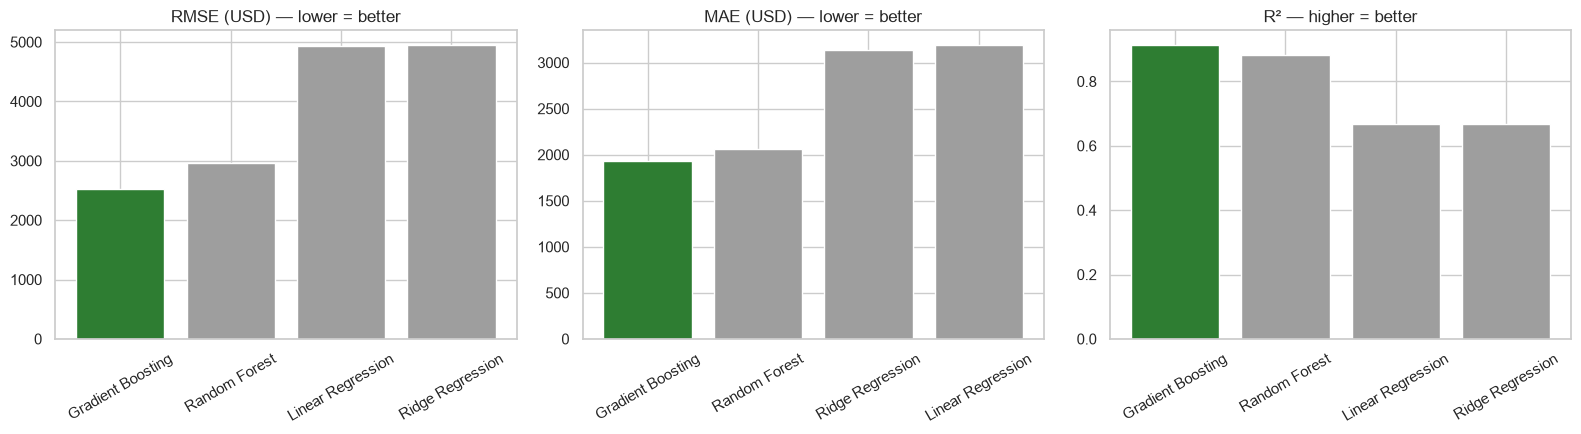

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metrics = [("rmse_usd", "RMSE (USD) — lower = better"),
           ("mae_usd", "MAE (USD) — lower = better"),
           ("r2", "R² — higher = better")]

for ax, (col, title) in zip(axes, metrics):
    order = results_df.sort_values(col, ascending=(col != "r2"))
    colors = ["#2E7D32" if i == 0 else "#9E9E9E" for i in range(len(order))]
    ax.bar(order["model"], order[col], color=colors)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

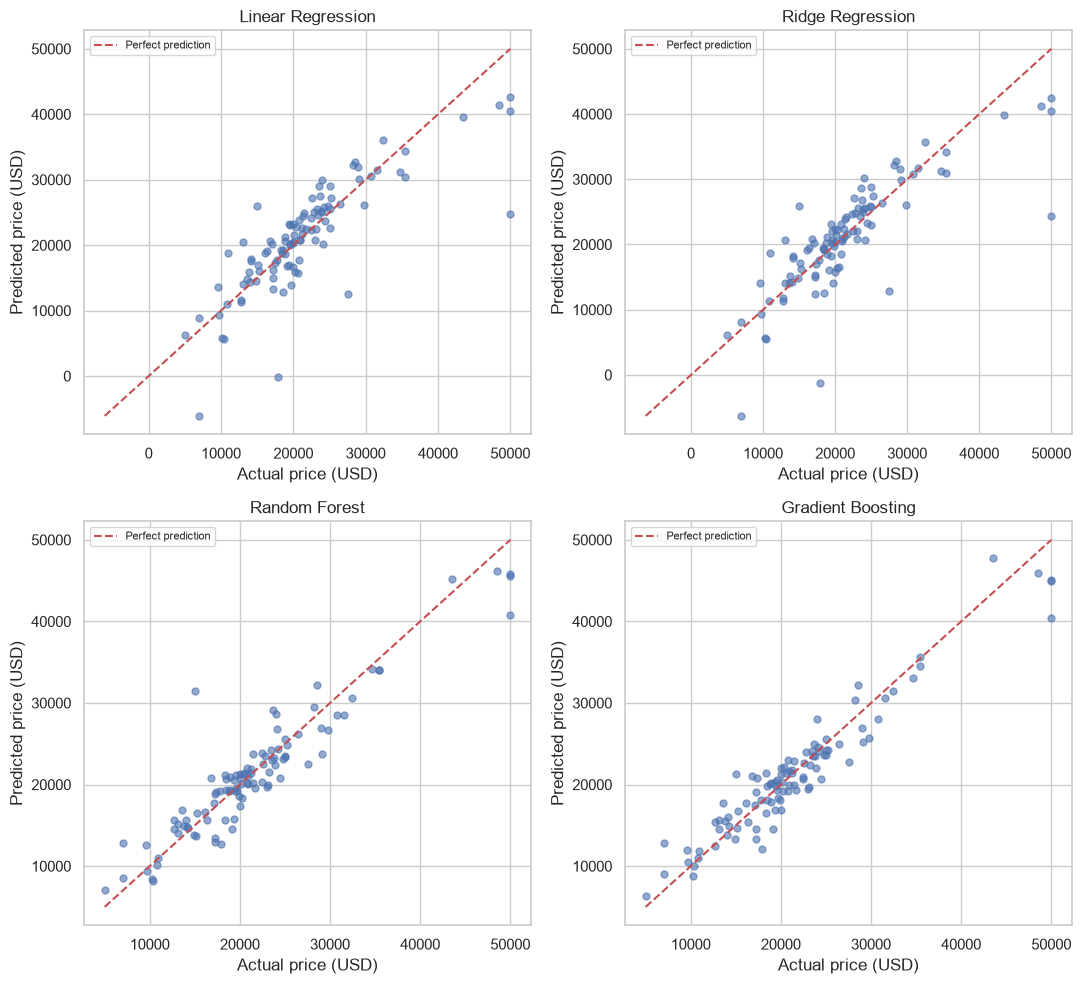

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
axes = axes.ravel()

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.6, s=25)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", label="Perfect prediction")
    ax.set_xlabel("Actual price (USD)")
    ax.set_ylabel("Predicted price (USD)")
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Best model selected**: the one with the lowest RMSE on the test set — there is no external threshold to reach, only a relative comparison between the tested models.

In [17]:
BEST_NAME = results_df.iloc[0]["model"]
BEST_MODEL = trained[BEST_NAME]
print(f"Best model: {BEST_NAME}")
print(results_df.iloc[0])

Best model: Gradient Boosting
model       Gradient Boosting
rmse_usd          2531.784262
mae_usd           1931.066301
r2                   0.912592
Name: 0, dtype: object


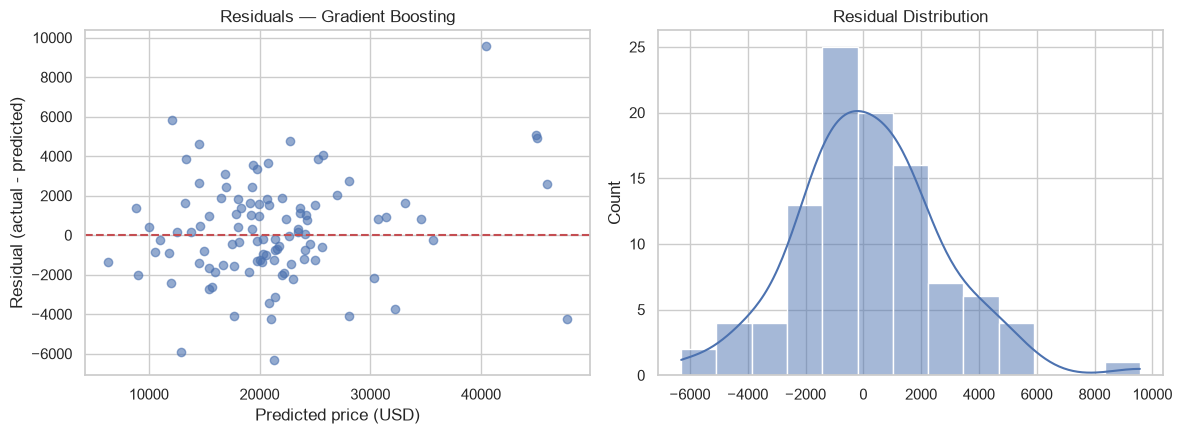

In [18]:
# Residuals of the best model
y_pred_best = predictions[BEST_NAME]
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_pred_best, residuals, alpha=0.6)
axes[0].axhline(0, color="r", linestyle="--")
axes[0].set_xlabel("Predicted price (USD)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title(f"Residuals — {BEST_NAME}")

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()

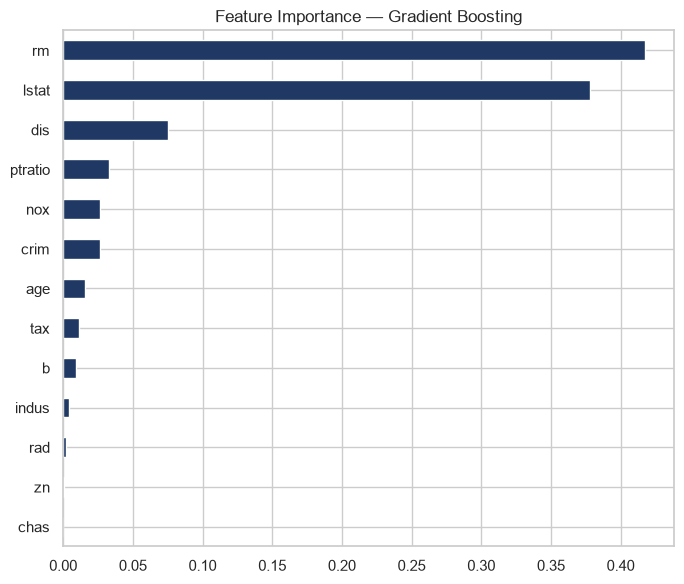

In [19]:
# Feature importance (if the best model supports it)
if hasattr(BEST_MODEL, "feature_importances_"):
    importances = pd.Series(BEST_MODEL.feature_importances_, index=FEATURES).sort_values(ascending=True)
    plt.figure(figsize=(7, 6))
    importances.plot(kind="barh", color="#1F3864")
    plt.title(f"Feature Importance — {BEST_NAME}")
    plt.tight_layout()
    plt.show()
elif hasattr(BEST_MODEL, "coef_"):
    coefs = pd.Series(BEST_MODEL.coef_, index=FEATURES).sort_values(key=abs, ascending=True)
    plt.figure(figsize=(7, 6))
    coefs.plot(kind="barh", color=["#2E7D32" if v > 0 else "#B00020" for v in coefs])
    plt.title(f"Model Coefficients — {BEST_NAME}")
    plt.tight_layout()
    plt.show()

## 6. Saving the Best Model (US-09)

In [20]:
model_filename = f"model_{BEST_NAME.lower().replace(' ', '_')}.joblib"
joblib.dump(BEST_MODEL, model_filename)
joblib.dump(FEATURES, "model_features.joblib")
results_df.to_json("models_comparison.json", orient="records", indent=2)

print(f"Selected model: {BEST_NAME}")
print(f"Files saved: {model_filename}, model_features.joblib, models_comparison.json")

Selected model: Gradient Boosting
Files saved: model_gradient_boosting.joblib, model_features.joblib, models_comparison.json


## POC Conclusion

- Technical feasibility demonstrated: 4 models trained and compared, the best one is saved.
- Since the business did not set an accuracy threshold, this POC can only be declared "validated" through a qualitative judgment call — to be arbitrated before moving to the MVP.
- Out of scope for this notebook (MVP): automated ETL pipeline (`US-04` to `US-06`), FastAPI API (`US-10` to `US-15`), containerization and CI/CD (`US-16` to `US-23`), observability (`US-24`, `US-25`).